# Spedition MLP — 5-Station Diesel Price Optimizer
**Szenario:** 5 LKWs fahren 5 feste Routen ab Aalen. Jede Route passiert eine Tankstelle ~25–30 km vom Ausgangspunkt.  
**Ziel:** 72h-Dieselpreisvorhersage für alle 5 Stationen → Dispozentrale empfiehlt günstigste Tankstelle.  
Vorgehen nach CRISP-DM (6 Phasen).

In [1]:
import sys, os
sys.path.insert(0, '..')
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
SEED = 42
TARGET_HORIZON = 72

project_root = os.path.abspath(os.path.join('..'))
docs_path = os.path.join(project_root, 'docs')
os.makedirs(docs_path, exist_ok=True)
fig_id = 1

def save_plot(plt, title_suffix=''):
    global fig_id
    ts = datetime.now().strftime('%Y-%m-%d-%H-%M-%S')
    path = os.path.join(docs_path, f'{ts}_{title_suffix}_{fig_id}.png')
    plt.savefig(path, dpi=plt.rcParams['figure.dpi'], bbox_inches='tight')
    print(f'Plot saved: {path}')
    fig_id += 1

print('Imports OK')

Imports OK


In [2]:
def compute_metrics_by_horizon(y_true, y_pred, base_targets, horizon):
    """MAE, RMSE, R² pro Horizont (1..horizon), gemittelt über alle Stationen."""
    rows = []
    for step in range(1, horizon + 1):
        cols = [f'{c}_t+{step}h' for c in base_targets]
        mae  = mean_absolute_error(y_true[cols], y_pred[cols], multioutput='uniform_average')
        rmse = np.sqrt(mean_squared_error(y_true[cols], y_pred[cols], multioutput='uniform_average'))
        r2   = r2_score(y_true[cols], y_pred[cols], multioutput='uniform_average')
        rows.append({'horizon_h': step, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    return pd.DataFrame(rows).set_index('horizon_h')


def build_persistence_baseline(X_data, y_data, base_targets, horizon):
    """Aktueller Preis als Vorhersage für alle Horizonte (naive Baseline)."""
    pred = pd.DataFrame(index=y_data.index, columns=y_data.columns, dtype=float)
    for step in range(1, horizon + 1):
        for s in base_targets:
            pred[f'{s}_t+{step}h'] = X_data[f'{s}_price_t'].values
    return pred


def print_metrics_summary(name, metrics_df):
    print(f'\n{name} — Performance je Horizont:')
    print(metrics_df.head(6).round(5))
    print('...')
    print(metrics_df.tail(3).round(5))
    m = metrics_df.mean()
    print(f'\n{name} Gesamt (Ø): MAE={m["MAE"]:.5f} €/L, RMSE={m["RMSE"]:.5f}, R²={m["R2"]:.4f}')

print('Hilfsfunktionen OK')

Hilfsfunktionen OK


---
## §1 Business Understanding
Eine Spedition betreibt 5 LKWs auf 5 festen Routen ab Aalen. Jede Route passiert genau eine Tankstelle in ~25–30 km Entfernung.
Der Disponent will wissen: **Welche Station wird in den nächsten 72 Stunden am günstigsten sein?**

In [3]:
# Flottenökonomie
TRUCKS        = 5
TANK_LITER    = 400          # L Tankfüllung je LKW
ROUTES_PER_DAY = 2           # Hin- und Rückfahrt
DAILY_FILLS   = TRUCKS * ROUTES_PER_DAY

print('=== Speditions-Flottenökonomie ===')
print(f'LKWs                 : {TRUCKS}')
print(f'Tankfüllung          : {TANK_LITER} L')
print(f'Befüllungen/Tag      : {DAILY_FILLS}')
print()

for diff_ct in [1, 2, 5]:
    diff = diff_ct / 100
    saving_per_fill = TANK_LITER * diff
    saving_day  = DAILY_FILLS * saving_per_fill
    saving_year = saving_day * 250
    print(f'Preisunterschied {diff_ct} ct/L → {saving_per_fill:.0f} €/Befüllung '
          f'→ {saving_day:.0f} €/Tag → {saving_year:.0f} €/Jahr')

print()
print('Erfolgskennzahl: Cheapest-Station Pick Accuracy')
print('  Random Baseline (5 Stationen): 20.0 %')
print('  Ziel: deutlich > 20 % auf Test-Set')

=== Speditions-Flottenökonomie ===
LKWs                 : 5
Tankfüllung          : 400 L
Befüllungen/Tag      : 10

Preisunterschied 1 ct/L → 4 €/Befüllung → 40 €/Tag → 10000 €/Jahr
Preisunterschied 2 ct/L → 8 €/Befüllung → 80 €/Tag → 20000 €/Jahr
Preisunterschied 5 ct/L → 20 €/Befüllung → 200 €/Tag → 50000 €/Jahr

Erfolgskennzahl: Cheapest-Station Pick Accuracy
  Random Baseline (5 Stationen): 20.0 %
  Ziel: deutlich > 20 % auf Test-Set


---
## §2 Data Understanding — Station Discovery
Kandidatenstationen: Haversine-Distanz zu Aalen-Zentrum, Filter 20–35 km, Einteilung in 5 Sektoren.

In [4]:
from dotenv import load_dotenv
load_dotenv(os.path.join(project_root, '.env'))

TANKERKOENIG_PATH = os.getenv('TANKERKOENIG_DATA_PATH', '../tankerkoenig-data')
data_path = os.path.join(project_root, TANKERKOENIG_PATH)
stations_csv = os.path.join(data_path, 'stations', 'stations.csv')

AALEN_LAT, AALEN_LON = 48.8374, 10.0936
RADIUS_MIN_KM, RADIUS_MAX_KM = 20, 35

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi    = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def bearing_deg(lat1, lon1, lat2, lon2):
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dlambda = np.radians(lon2 - lon1)
    x = np.sin(dlambda) * np.cos(phi2)
    y = np.cos(phi1)*np.sin(phi2) - np.sin(phi1)*np.cos(phi2)*np.cos(dlambda)
    return (np.degrees(np.arctan2(x, y)) + 360) % 360

# 5 Sektoren: N, NE, SE, S, W  (Bearing-Grenzen in Grad)
SECTORS = {
    'N':  (337.5, 22.5),
    'NE': (22.5,  90.0),
    'SE': (90.0, 157.5),
    'S':  (157.5, 225.0),
    'W':  (225.0, 337.5),
}
SECTOR_COLORS = {'N': 'blue', 'NE': 'orange', 'SE': 'green', 'S': 'red', 'W': 'purple'}

def classify_sector(bearing):
    for name, (lo, hi) in SECTORS.items():
        if lo > hi:  # N wraps around 0
            if bearing >= lo or bearing < hi:
                return name
        elif lo <= bearing < hi:
            return name
    return 'N'

print('Geo-Hilfsfunktionen OK')

Geo-Hilfsfunktionen OK


In [5]:
# Alle Stationen laden
stations = pd.read_csv(
    stations_csv,
    dtype={'uuid': str, 'post_code': str},
    low_memory=False,
)
print(f'Stationen gesamt: {len(stations):,}')
print(f'Spalten: {list(stations.columns)}')

Stationen gesamt: 15,442
Spalten: ['uuid', 'name', 'brand', 'street', 'house_number', 'post_code', 'city', 'latitude', 'longitude']


In [6]:
# Distanz und Bearing berechnen
stations = stations.dropna(subset=['latitude', 'longitude'])

stations['dist_km'] = haversine_km(
    AALEN_LAT, AALEN_LON,
    stations['latitude'].values, stations['longitude'].values
)
stations['bearing'] = bearing_deg(
    AALEN_LAT, AALEN_LON,
    stations['latitude'].values, stations['longitude'].values
)
stations['sector'] = stations['bearing'].apply(classify_sector)

# Radius-Filter
candidates = stations[
    (stations['dist_km'] >= RADIUS_MIN_KM) &
    (stations['dist_km'] <= RADIUS_MAX_KM)
].copy()

print(f'Kandidatenstationen ({RADIUS_MIN_KM}–{RADIUS_MAX_KM} km): {len(candidates)}')
print(candidates.groupby('sector').size().rename('Anzahl'))

Kandidatenstationen (20–35 km): 86
sector
N      9
NE    15
S     15
SE     7
W     40
Name: Anzahl, dtype: int64


folium nicht installiert. Statische Karte:
Plot saved: /Volumes/scratch-apfs-owc-1/PredAna_Python/SpritpreisAnalyse_HSAA_PredAnal/docs/2026-05-29-17-03-31_spedition_station_map_1.png


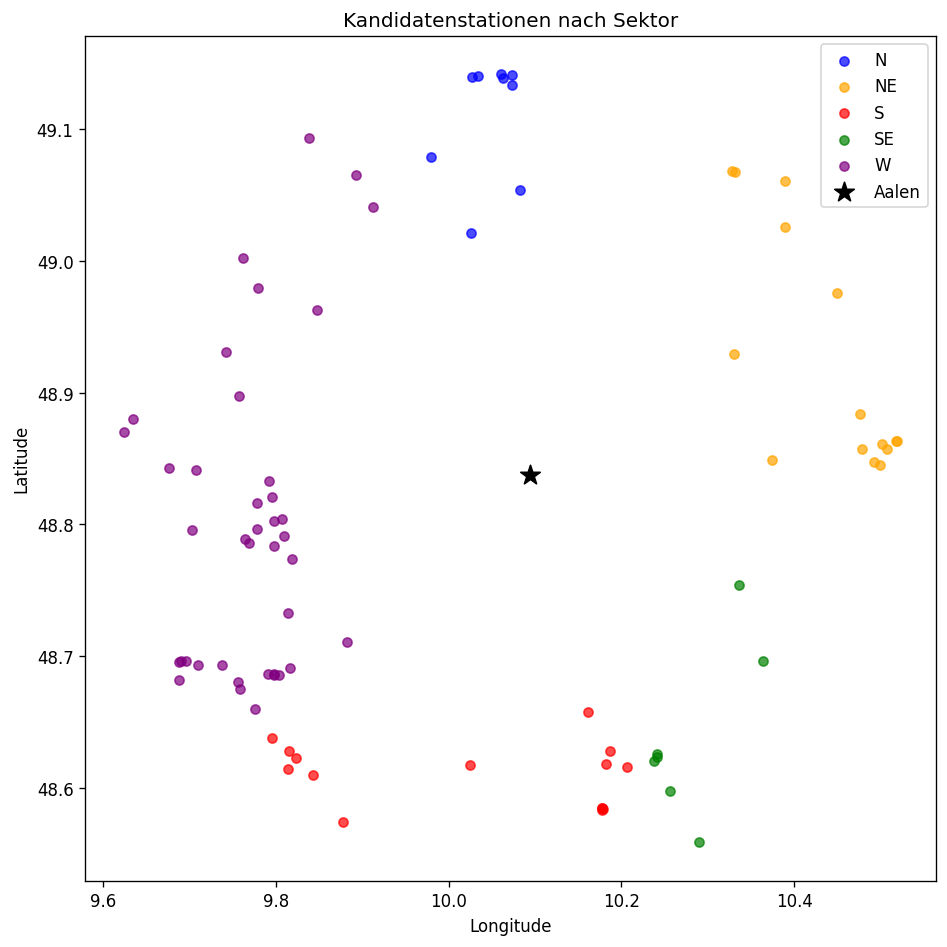

In [7]:
try:
    import folium
    m = folium.Map(location=[AALEN_LAT, AALEN_LON], zoom_start=10)

    # Aalen-Zentrum
    folium.Marker(
        [AALEN_LAT, AALEN_LON],
        tooltip='Aalen (Zentrum)',
        icon=folium.Icon(color='black', icon='home')
    ).add_to(m)

    # Radius-Kreise
    for r in [RADIUS_MIN_KM, RADIUS_MAX_KM]:
        folium.Circle(
            [AALEN_LAT, AALEN_LON], radius=r * 1000,
            color='gray', fill=False, opacity=0.4, weight=1
        ).add_to(m)

    # Kandidatenstationen
    for _, row in candidates.iterrows():
        name  = f"{row.get('brand', '')} {row.get('name', '')} ({row.get('city', '')})"
        popup = f"UUID: {row['uuid']}<br>Distanz: {row['dist_km']:.1f} km<br>Sektor: {row['sector']}"
        folium.CircleMarker(
            [row['latitude'], row['longitude']],
            radius=5,
            color=SECTOR_COLORS[row['sector']],
            fill=True, fill_opacity=0.7,
            tooltip=name, popup=popup
        ).add_to(m)

    display(m)
except ImportError:
    print('folium nicht installiert. Statische Karte:')
    fig, ax = plt.subplots(figsize=(8, 8))
    for sector, grp in candidates.groupby('sector'):
        ax.scatter(grp['longitude'], grp['latitude'],
                   c=SECTOR_COLORS[sector], label=sector, s=30, alpha=0.7)
    ax.scatter(AALEN_LON, AALEN_LAT, c='black', s=150, marker='*', zorder=5, label='Aalen')
    ax.set(xlabel='Longitude', ylabel='Latitude', title='Kandidatenstationen nach Sektor')
    ax.legend()
    plt.tight_layout()
    save_plot(plt, 'spedition_station_map')
    plt.show()

In [8]:
# Datenverfügbarkeit: first_active je Station als Proxy für Datenlänge
display_cols = ['uuid', 'name', 'brand', 'city', 'dist_km', 'bearing', 'sector']
if 'first_active' in candidates.columns:
    candidates['first_active'] = pd.to_datetime(candidates['first_active'], errors='coerce')
    display_cols.append('first_active')

avail = candidates[display_cols].sort_values(['sector', 'dist_km'])

print('Kandidatenstationen je Sektor (sortiert nach Distanz):')
for sector in ['N', 'NE', 'SE', 'S', 'W']:
    grp = avail[avail['sector'] == sector]
    print(f'\n--- Sektor {sector} ({len(grp)} Stationen) ---')
    print(grp[['uuid', 'name', 'brand', 'city', 'dist_km']].to_string(index=False))

Kandidatenstationen je Sektor (sortiert nach Distanz):

--- Sektor N (9 Stationen) ---
                                uuid                                name       brand                      city   dist_km
dd445625-f059-40b7-9b42-6166173b5c43                        AVIA Station        AVIA                 Rosenberg 21.011563
0b7b03b2-feb8-4c6d-9e65-053003a7e450        AVIA Xpress Automatenstation AVIA Xpress    Stimpfach-Randenweiler 24.078501
b6001f07-0bcf-43ab-bc2f-6a0a67aa97fe                        AVIA Station        AVIA Frankenhardt-Gründelhardt 28.062125
5f3e4cb8-4fba-4ae1-b047-ce33591d9b46           CRAILSHEIM, ELLWANGER STR       Shell                Crailsheim 32.959092
5a17f46a-41a2-47bb-959c-32b3d47a4baa                     Aral Tankstelle        ARAL                Crailsheim 33.576258
b0bf848e-f960-4947-afd0-dba4fc16ec5d     CRAILSHEIM - BLAUFELDER STRASSE        Agip                Crailsheim 33.751338
e1a15081-25a7-9107-e040-0b0a3dfe563c          Crailsheim, Haller S

### ⬇️ Benutzeraktion: Stationen auswählen
Wähle je Sektor **eine** Station aus der obigen Liste aus (beste Datenverfügbarkeit + sinnvolle Route).
Trage UUID und Name in die Zelle unten ein.

In [9]:
# ── HIER AUSFÜLLEN ──────────────────────────────────────────────────────────
# Ersetze die Platzhalter mit den UUIDs aus der Karte/Tabelle oben.
# Je Sektor eine Station. Die Namen werden als Spaltenpräfix in X und y verwendet.

STATION_UUIDS = {
    # Sektor N  (~Ellwangen/Rainau)
    'Station_N':  '5a17f46a-41a2-47bb-959c-32b3d47a4baa',
    # Sektor NE (~Bopfingen/Nördlingen-Richtung)
    'Station_NE': 'db3438c3-c0a3-4a91-8703-37bc8e90369c',
    # Sektor SE (~Heidenheim/Giengen)
    'Station_SE': '1ce6fda2-5a32-47eb-bb79-04b94e19e80b',
    # Sektor S  (~Schwäbisch Gmünd Süd/Lorch)
    'Station_S':  '3bba6a5d-ed98-4fd8-8c97-6de9ae7e8fa1',
    # Sektor W  (~Oberkochen/Königsbronn)
    'Station_W':  'a6e56fe5-e9aa-4ed5-8281-2b0382538893',
}
# ────────────────────────────────────────────────────────────────────────────

print('Ausgewählte Stationen:')
for name, uuid in STATION_UUIDS.items():
    match = candidates[candidates['uuid'] == uuid]
    if not match.empty:
        row = match.iloc[0]
        print(f'  {name:15s} | {row.get("brand",""):10s} {row.get("city",""):20s} | {row["dist_km"]:.1f} km | {uuid}')
    else:
        print(f'  {name:15s} | UUID nicht in Kandidatenliste: {uuid}')

Ausgewählte Stationen:
  Station_N       | ARAL       Crailsheim           | 33.6 km | 5a17f46a-41a2-47bb-959c-32b3d47a4baa
  Station_NE      | OMV        Dinkelsbühl          | 30.8 km | db3438c3-c0a3-4a91-8703-37bc8e90369c
  Station_SE      | ARAL       Hermaringen          | 29.2 km | 1ce6fda2-5a32-47eb-bb79-04b94e19e80b
  Station_S       | ARAL       Geislingen           | 31.3 km | 3bba6a5d-ed98-4fd8-8c97-6de9ae7e8fa1
  Station_W       | ARAL       Gaildorf             | 27.9 km | a6e56fe5-e9aa-4ed5-8281-2b0382538893


In [10]:
# Preis-Zeitreihen der 5 Stationen visualisieren (aus Parquet-Cache oder Rohdaten)
from scripts.data_transform_spedition import SpeditionDataLoader

loader = SpeditionDataLoader(
    forecast_horizon=TARGET_HORIZON,
    fuel_type='diesel',
    cache=True,
    debug=True,
    station_uuids=STATION_UUIDS,
)
X, y = loader.load()

base_targets = sorted({c.rsplit('_t+', 1)[0] for c in y.columns})
y_t1 = y[[f'{c}_t+1h' for c in base_targets]].copy()
y_t1.columns = base_targets

print(f'Zeitraum  : {y.index[0]}  →  {y.index[-1]}')
print(f'Stationen : {base_targets}')
print(f'Horizonte : t+1h … t+{TARGET_HORIZON}h  ({y.shape[1]} Target-Spalten)')

[SpeditionDataLoader] DEBUG mode enabled
  Stations: ['Station_N', 'Station_NE', 'Station_SE', 'Station_S', 'Station_W']
[SpeditionDataLoader] Loading from cache: /Volumes/scratch-apfs-owc-1/PredAna_Python/SpritpreisAnalyse_HSAA_PredAnal/notebooks/../data/processed/spedition_5stations_diesel.parquet
[SpeditionDataLoader] Feature matrix ready: X=(104507, 99), y=(104507, 360)
Zeitraum  : 2014-06-15 09:00:00  →  2026-05-17 19:00:00
Stationen : ['diesel_Station_N', 'diesel_Station_NE', 'diesel_Station_S', 'diesel_Station_SE', 'diesel_Station_W']
Horizonte : t+1h … t+72h  (360 Target-Spalten)


Plot saved: /Volumes/scratch-apfs-owc-1/PredAna_Python/SpritpreisAnalyse_HSAA_PredAnal/docs/2026-05-29-17-03-33_spedition_eda_price_history_2.png


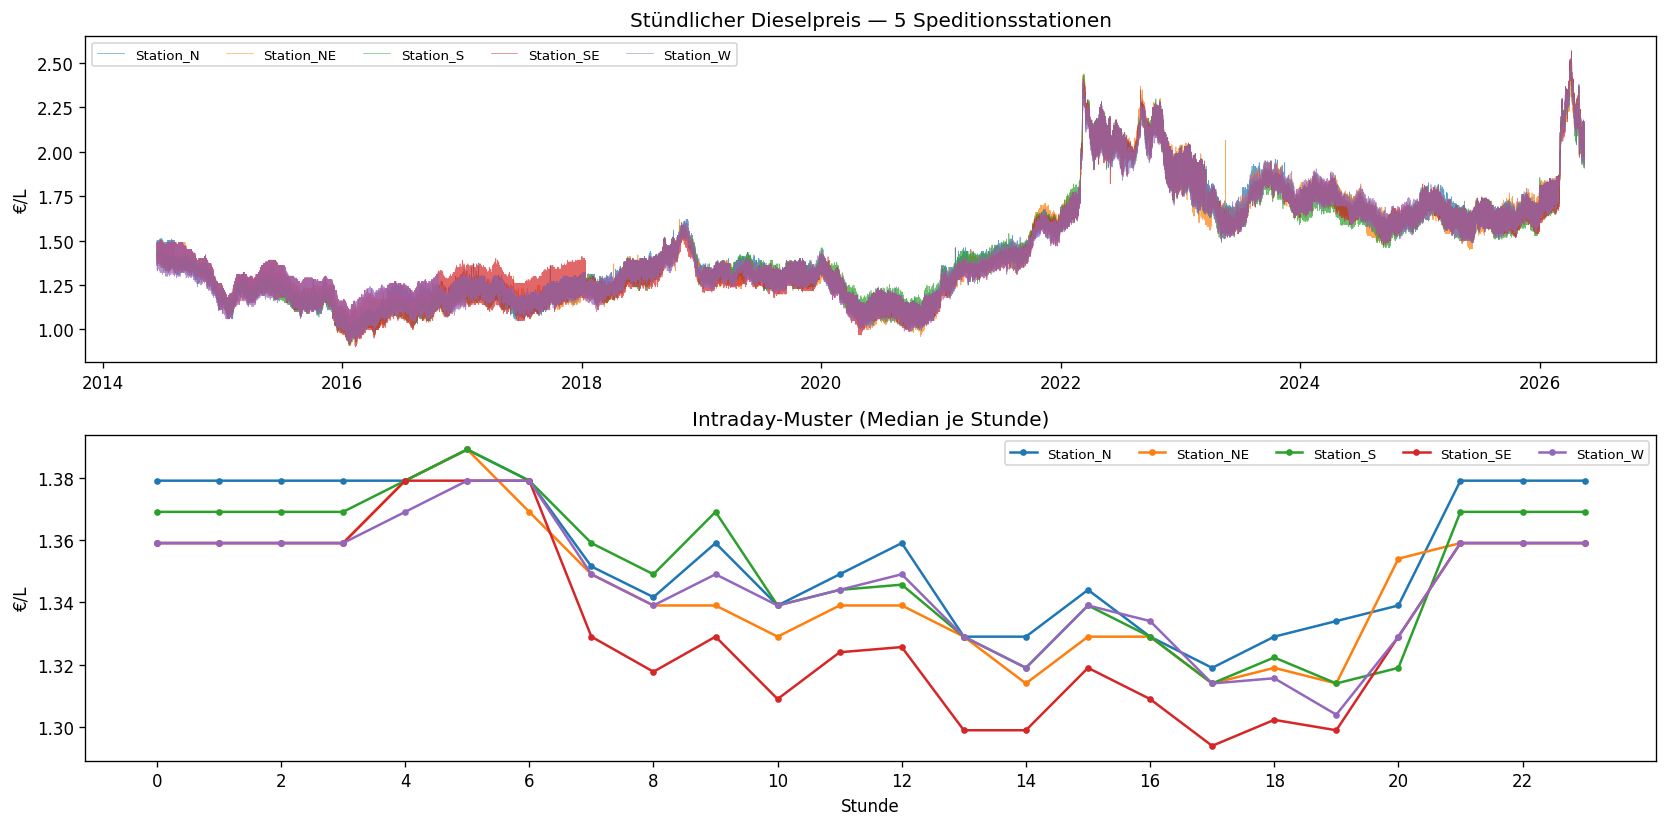

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Zeitverlauf
ax = axes[0]
for col in y_t1.columns:
    ax.plot(y_t1.index, y_t1[col], lw=0.4, alpha=0.7, label=col.replace('diesel_', ''))
ax.set(title='Stündlicher Dieselpreis — 5 Speditionsstationen',
       ylabel='€/L')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(ncol=5, fontsize=8)

# Intraday-Muster
ax = axes[1]
for col in y_t1.columns:
    intraday = y_t1[col].groupby(y_t1.index.hour).median()
    ax.plot(intraday.index, intraday.values, marker='o', ms=3,
            label=col.replace('diesel_', ''))
ax.set(title='Intraday-Muster (Median je Stunde)',
       xlabel='Stunde', ylabel='€/L')
ax.set_xticks(range(0, 24, 2))
ax.legend(ncol=5, fontsize=8)

plt.tight_layout()
save_plot(plt, 'spedition_eda_price_history')
plt.show()

Plot saved: /Volumes/scratch-apfs-owc-1/PredAna_Python/SpritpreisAnalyse_HSAA_PredAnal/docs/2026-05-29-17-03-34_spedition_correlation_3.png


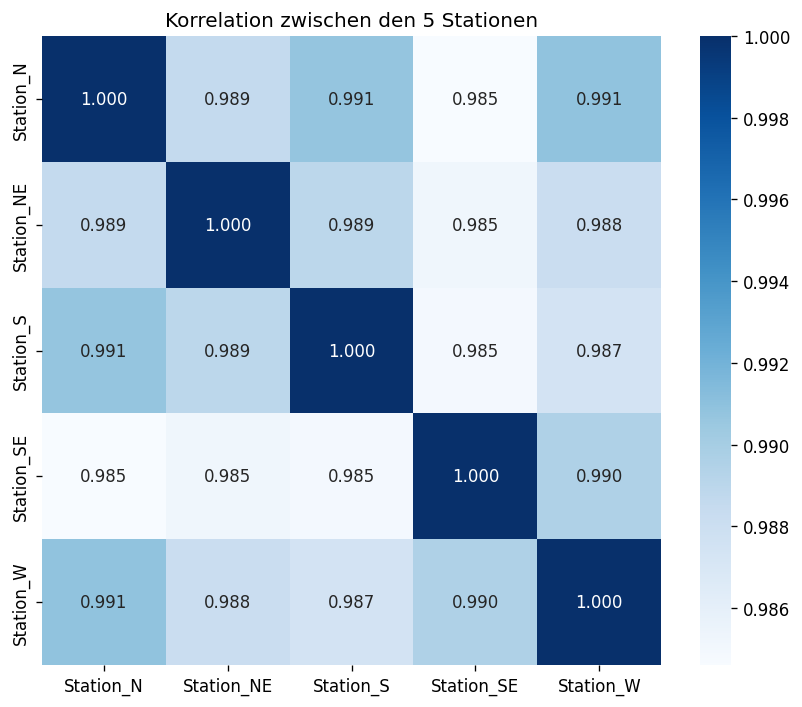


Deskriptive Statistik:


,diesel_Station_N,diesel_Station_NE,diesel_Station_S,diesel_Station_SE,diesel_Station_W
count,104507.0000,104507.0000,104507.0000,104507.0000,104507.0000
mean,1.4573,1.4437,1.4371,1.4330,1.4458
std,0.3002,0.2993,0.2917,0.2949,0.2956
min,0.9490,0.9290,0.9090,0.8990,0.9190
25%,1.2190,1.2090,1.1990,1.2090,1.2190
50%,1.3590,1.3490,1.3490,1.3490,1.3490
75%,1.6790,1.6490,1.6315,1.6390,1.6640
max,2.5690,2.5190,2.5390,2.5690,2.5390


In [12]:
# Korrelationsmatrix
labels = [c.replace('diesel_', '') for c in y_t1.columns]
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(y_t1.corr(), annot=True, fmt='.3f', cmap='Blues', ax=ax,
            xticklabels=labels, yticklabels=labels)
ax.set_title('Korrelation zwischen den 5 Stationen')
plt.tight_layout()
save_plot(plt, 'spedition_correlation')
plt.show()

print('\nDeskriptive Statistik:')
y_t1.describe().round(4)

---
## §3 Data Preparation
`SpeditionDataLoader` hat alle Features berechnet (Lags, Rolling, Trend, Momentum, Zeitmerkmale).  
Hier: Feature-Übersicht, NaN-Check, Temporal-Split, Skalierung.

In [13]:
print(f'Feature-Matrix X : {X.shape}')
print(f'Target-Matrix  y : {y.shape}')
print(f'Stationen: {len(base_targets)}, Horizonte je Station: {TARGET_HORIZON}')
print(f'Output-Neuronen: {len(base_targets)} × {TARGET_HORIZON} = {len(base_targets) * TARGET_HORIZON}')

groups = {
    'Lag-Features':     [c for c in X.columns if '_lag_' in c],
    'Price_t':          [c for c in X.columns if c.endswith('_price_t')],
    'Rolling':          [c for c in X.columns if '_roll_' in c],
    'Diff/Momentum':    [c for c in X.columns if '_diff' in c or '_momentum' in c],
    'Trend':            [c for c in X.columns if '_trend' in c],
    'Zeitmerkmale':     ['hour', 'day_of_week', 'is_weekend', 'is_holiday'],
}
print('\nFeature-Gruppen:')
total = 0
for name, cols in groups.items():
    n = len([c for c in cols if c in X.columns])
    print(f'  {name:20s}: {n:3d} Spalten')
    total += n
print(f'  {"─"*20}──────────')
print(f'  {"Total":20s}: {X.shape[1]:3d} Spalten')

Feature-Matrix X : (104507, 99)
Target-Matrix  y : (104507, 360)
Stationen: 5, Horizonte je Station: 72
Output-Neuronen: 5 × 72 = 360

Feature-Gruppen:
  Lag-Features        :  45 Spalten
  Price_t             :   5 Spalten
  Rolling             :  30 Spalten
  Diff/Momentum       :  10 Spalten
  Trend               :   5 Spalten
  Zeitmerkmale        :   4 Spalten
  ──────────────────────────────
  Total               :  99 Spalten


In [14]:
nan_x = X.isna().sum().sum()
nan_y = y.isna().sum().sum()
print(f'NaN in X: {nan_x}  ({nan_x/X.size*100:.2f}%)')
print(f'NaN in y: {nan_y}  ({nan_y/y.size*100:.2f}%)')

valid_idx = X.dropna().index.intersection(y.dropna().index)
X, y = X.loc[valid_idx], y.loc[valid_idx]
print(f'Bereinigte Größe: X={X.shape}, y={y.shape}')

warmup_lost = 168
target_lost = TARGET_HORIZON
print(f'\nZeilenverlust: {warmup_lost} (Warmup/Lags) + {target_lost} (Targets am Ende) = {warmup_lost + target_lost} Zeilen')

NaN in X: 0  (0.00%)
NaN in y: 0  (0.00%)
Bereinigte Größe: X=(104507, 99), y=(104507, 360)

Zeilenverlust: 168 (Warmup/Lags) + 72 (Targets am Ende) = 240 Zeilen


In [15]:
# Temporaler Split
X_train, X_val, X_test, y_train, y_val, y_test = loader.train_val_test_split(X, y)

# Skalierung (fit nur auf Train — kein Data Leakage)
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_val_s   = scaler_X.transform(X_val)
X_test_s  = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_s = scaler_y.fit_transform(y_train)
y_val_s   = scaler_y.transform(y_val)

print('Scaler fitted auf Train-Set — kein Data Leakage.')

  Train : 2014-06-15 09:00:00  →  2021-12-31 23:00:00  (66,159 rows)
  Val   : 2022-01-01 00:00:00  →  2023-12-31 23:00:00  (17,520 rows)
  Test  : 2024-01-01 00:00:00  →  2026-05-17 19:00:00  (20,828 rows)
Scaler fitted auf Train-Set — kein Data Leakage.


---
## §4 Modeling
**Baseline:** Persistence (aktueller Preis = Vorhersage für alle 72h)  
**Modell:** MLPRegressor — direkte Mehrschritt-Vorhersage aller 5×72 = 360 Targets  
**CV:** TimeSeriesSplit (5 Folds) zur Architekturvalidierung

In [16]:
# Pipeline: Scaler wird pro CV-Fold neu gefittet → kein Leakage in der CV
pipe_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(
        hidden_layer_sizes=(256, 128),
        activation='relu',
        solver='adam',
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=SEED,
        verbose=False,
    )),
])
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(
    pipe_cv, X_train, y_train_s,   # X_train (unskaliert!) — Scaler fittet pro Fold
    cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1
)
cv_mae = -cv_scores
print('TimeSeriesSplit CV (5 Folds) — MAE (skalierte Targets):')
print(f'  Folds : {np.round(cv_mae, 5)}')
print(f'  Mean  : {cv_mae.mean():.5f} ± {cv_mae.std():.5f}')

TimeSeriesSplit CV (5 Folds) — MAE (skalierte Targets):
  Folds : [0.24304 0.19838 0.21557 0.19217 0.17837]
  Mean  : 0.20550 ± 0.02225


In [17]:
model = MLPRegressor(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=SEED,
    verbose=True,
)
model.fit(X_train_s, y_train_s)

n_in  = X_train_s.shape[1]
n_out = y_train_s.shape[1]
h1, h2 = model.hidden_layer_sizes
print(f'\nMLP-Architektur: {n_in} → [{h1}] → [{h2}] → {n_out}')
print(f'  Input-Neuronen : {n_in} (Features)')
print(f'  Output-Neuronen: {n_out} ({len(base_targets)} Stationen × {TARGET_HORIZON} Horizonte)')
print(f'  Effektive Epochen: {model.n_iter_},  Final loss: {model.loss_:.6f}')

Iteration 1, loss = 0.05797241
Validation score: 0.941055
Iteration 2, loss = 0.02691684
Validation score: 0.949284
Iteration 3, loss = 0.02415328
Validation score: 0.953144
Iteration 4, loss = 0.02251035
Validation score: 0.955549
Iteration 5, loss = 0.02138373
Validation score: 0.956838
Iteration 6, loss = 0.02066187
Validation score: 0.959022
Iteration 7, loss = 0.02007145
Validation score: 0.960308
Iteration 8, loss = 0.01964134
Validation score: 0.960933
Iteration 9, loss = 0.01918054
Validation score: 0.961139
Iteration 10, loss = 0.01880842
Validation score: 0.962300
Iteration 11, loss = 0.01856371
Validation score: 0.960649
Iteration 12, loss = 0.01828467
Validation score: 0.963310
Iteration 13, loss = 0.01807005
Validation score: 0.963245
Iteration 14, loss = 0.01789532
Validation score: 0.964069
Iteration 15, loss = 0.01767030
Validation score: 0.963754
Iteration 16, loss = 0.01756341
Validation score: 0.964597
Iteration 17, loss = 0.01733581
Validation score: 0.965125
Iterat

Plot saved: /Volumes/scratch-apfs-owc-1/PredAna_Python/SpritpreisAnalyse_HSAA_PredAnal/docs/2026-05-29-17-07-22_spedition_mlp_loss_curve_4.png


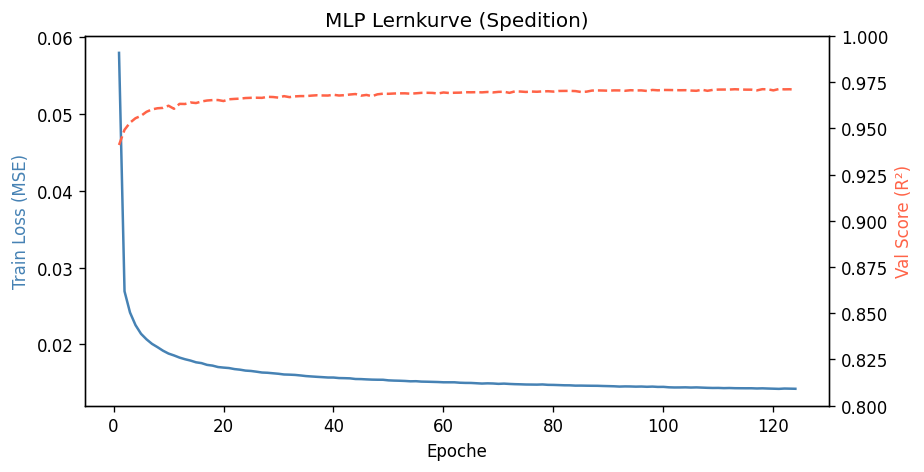

In [18]:
epochs = np.arange(1, len(model.loss_curve_) + 1)
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(epochs, model.loss_curve_, color='steelblue', label='Train Loss (MSE)')
ax1.set_ylabel('Train Loss (MSE)', color='steelblue')
if hasattr(model, 'validation_scores_'):
    ax2 = ax1.twinx()
    ax2.plot(epochs[:len(model.validation_scores_)], model.validation_scores_,
             ls='--', color='tomato', label='Val Score (R²)')
    ax2.set_ylabel('Val Score (R²)', color='tomato')
    ax2.set_ylim(0.8, 1)
ax1.set_xlabel('Epoche')
plt.title('MLP Lernkurve (Spedition)')
save_plot(plt, 'spedition_mlp_loss_curve')
plt.show()

---
## §5 Evaluation
Test-Set (2024–heute): MAE/RMSE je Horizont, Cheapest-Station Pick Accuracy, Spearman-Ranking, Kosten-Impact.

In [19]:
y_test_pred_raw = scaler_y.inverse_transform(model.predict(X_test_s))
y_test_pred = pd.DataFrame(y_test_pred_raw, index=y_test.index, columns=y.columns)

persist_pred = build_persistence_baseline(X_test, y_test, base_targets, TARGET_HORIZON)

test_metrics    = compute_metrics_by_horizon(y_test, y_test_pred, base_targets, TARGET_HORIZON)
persist_metrics = compute_metrics_by_horizon(y_test, persist_pred, base_targets, TARGET_HORIZON)

print_metrics_summary('MLP', test_metrics)
print_metrics_summary('Persistence', persist_metrics)

mae_improv  = (persist_metrics['MAE'].mean() - test_metrics['MAE'].mean()) / persist_metrics['MAE'].mean() * 100
rmse_skill  = 1 - (test_metrics['RMSE'].mean() / persist_metrics['RMSE'].mean())
print(f'\nVerbesserung ggü. Persistence (MAE): {mae_improv:.1f}%')
print(f'RMSE Skill Score: {rmse_skill:.1%}')


MLP — Performance je Horizont:
               MAE     RMSE       R2
horizon_h                           
1          0.02475  0.03269  0.96365
2          0.02743  0.03615  0.95558
3          0.02653  0.03494  0.95851
4          0.02828  0.03712  0.95317
5          0.02912  0.03736  0.95252
6          0.03109  0.03898  0.94856
...
               MAE     RMSE       R2
horizon_h                           
70         0.03274  0.04634  0.92790
71         0.03412  0.04848  0.92105
72         0.03189  0.04552  0.93033

MLP Gesamt (Ø): MAE=0.03444 €/L, RMSE=0.04545, R²=0.9291

Persistence — Performance je Horizont:
               MAE     RMSE       R2
horizon_h                           
1          0.02180  0.03576  0.95667
2          0.02537  0.04234  0.93943
3          0.03341  0.04961  0.91696
4          0.03691  0.05409  0.90118
5          0.04091  0.05655  0.89190
6          0.04223  0.05695  0.89026
...
               MAE     RMSE       R2
horizon_h                           
70         

Plot saved: /Volumes/scratch-apfs-owc-1/PredAna_Python/SpritpreisAnalyse_HSAA_PredAnal/docs/2026-05-29-17-07-22_spedition_mlp_vs_persistence_by_horizon_5.png


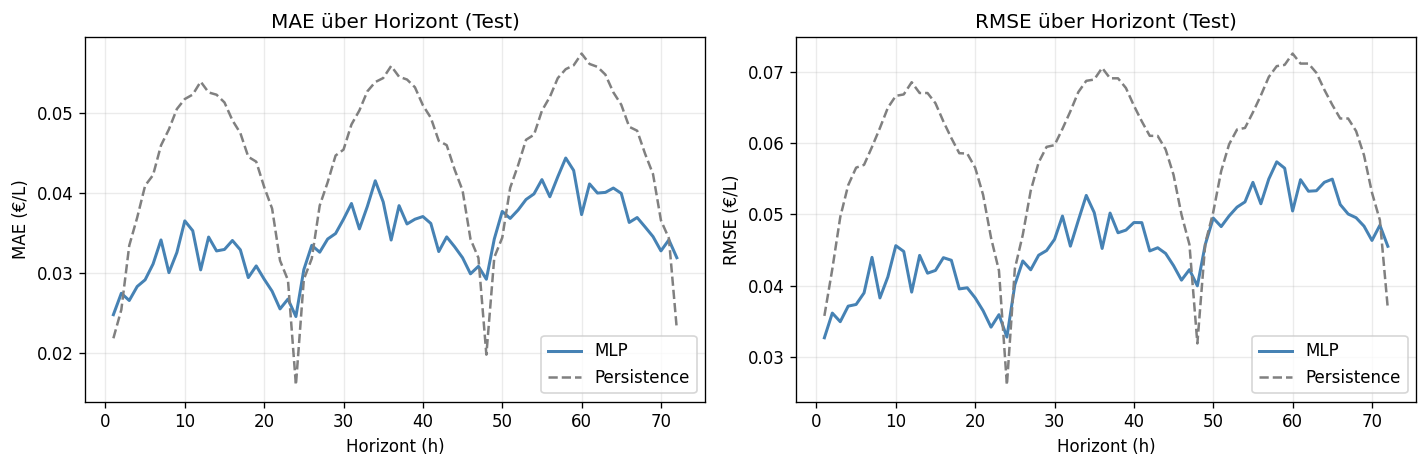

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for ax, metric, ylabel in zip(axes, ['MAE', 'RMSE'], ['MAE (€/L)', 'RMSE (€/L)']):
    ax.plot(test_metrics.index, test_metrics[metric], label='MLP', color='steelblue', lw=1.8)
    ax.plot(persist_metrics.index, persist_metrics[metric], label='Persistence',
            color='gray', lw=1.5, ls='--')
    ax.set(title=f'{metric} über Horizont (Test)', xlabel='Horizont (h)', ylabel=ylabel)
    ax.grid(alpha=0.25)
    ax.legend()
plt.tight_layout()
save_plot(plt, 'spedition_mlp_vs_persistence_by_horizon')
plt.show()

Cheapest-Station Pick Accuracy:
  Random Baseline (1/5): 20.0%
  MLP Gesamt (Ø)  : 32.7%
  Verbesserung    : +12.7% Prozentpunkte

Erste 6 Horizonte:
           pick_accuracy
horizon_h               
1                  0.568
2                  0.512
3                  0.483
4                  0.460
5                  0.423
6                  0.365
Plot saved: /Volumes/scratch-apfs-owc-1/PredAna_Python/SpritpreisAnalyse_HSAA_PredAnal/docs/2026-05-29-17-07-23_spedition_pick_accuracy_6.png


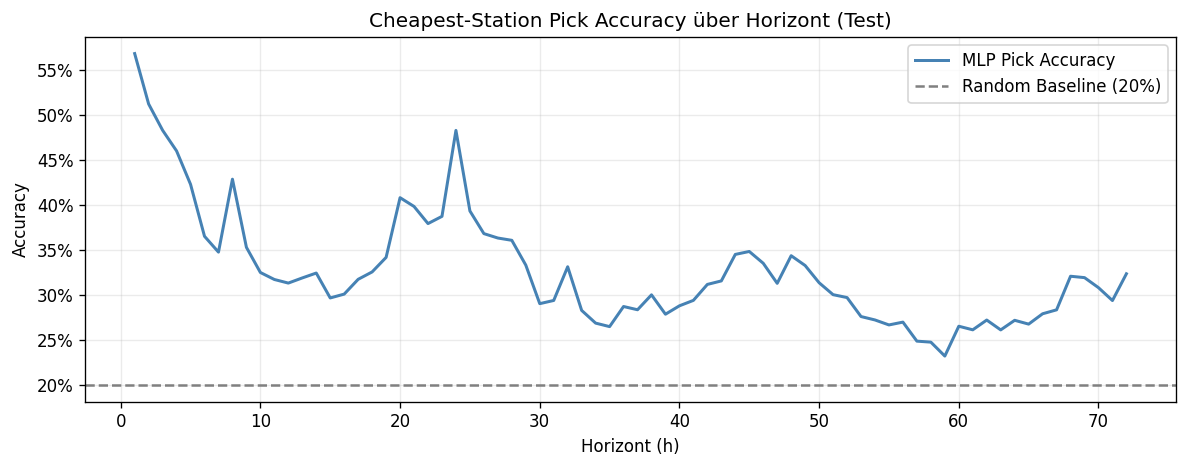

In [21]:
# Cheapest-station pick accuracy
# Für jeden Zeitpunkt und Horizont: Welche Station ist am günstigsten?

n_stations = len(base_targets)
pick_accuracies = []

for step in range(1, TARGET_HORIZON + 1):
    true_cols = [f'{s}_t+{step}h' for s in base_targets]
    pred_cols = [f'{s}_t+{step}h' for s in base_targets]

    true_cheapest = y_test[true_cols].values.argmin(axis=1)
    pred_cheapest = y_test_pred[pred_cols].values.argmin(axis=1)

    acc = (true_cheapest == pred_cheapest).mean()
    pick_accuracies.append({'horizon_h': step, 'pick_accuracy': acc})

pick_df = pd.DataFrame(pick_accuracies).set_index('horizon_h')
mean_acc = pick_df['pick_accuracy'].mean()
random_baseline = 1 / n_stations

print(f'Cheapest-Station Pick Accuracy:')
print(f'  Random Baseline (1/{n_stations}): {random_baseline:.1%}')
print(f'  MLP Gesamt (Ø)  : {mean_acc:.1%}')
print(f'  Verbesserung    : +{mean_acc - random_baseline:.1%} Prozentpunkte')
print(f'\nErste 6 Horizonte:')
print(pick_df.head(6).round(3))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(pick_df.index, pick_df['pick_accuracy'], color='steelblue', lw=1.8, label='MLP Pick Accuracy')
ax.axhline(random_baseline, color='gray', ls='--', label=f'Random Baseline ({random_baseline:.0%})')
ax.set(title='Cheapest-Station Pick Accuracy über Horizont (Test)',
       xlabel='Horizont (h)', ylabel='Accuracy')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
save_plot(plt, 'spedition_pick_accuracy')
plt.show()

### Spearman-Ranking-Korrelation
Was gemessen wird: Nicht wie genau der absolute Preis getroffen wird (das macht MAE/RMSE), sondern ob das Modell die relative Reihenfolge der 5 Stationen korrekt vorhersagt.

Konkret für jeden Zeitpunkt t und Horizont +h:

Angenommen die echten Preise um t+8h sind:
Station_N:  1.789 €  →  Rang 3

Station_NE: 1.752 €  →  Rang 1  (günstigste)

Station_SE: 1.801 €  →  Rang 5

Station_S:  1.774 €  →  Rang 2

Station_W:  1.796 €  →  Rang 4

Das Modell sagt vorher:
Station_N:  1.800 €  →  Rang 3  ✓

Station_NE: 1.760 €  →  Rang 1  ✓

Station_SE: 1.820 €  →  Rang 5  ✓

Station_S:  1.780 €  →  Rang 2  ✓

Station_W:  1.810 €  →  Rang 4  ✓

→ Spearman ρ = 1.0 (perfekte Übereinstimmung), obwohl die absoluten Preise daneben liegen.

#### Warum das für die Spedition wichtiger ist als MAE
Der Disponent braucht keine exakten Preise — er will wissen welche Station günstiger ist. Ein Modell das systematisch alle Preise um 5 ct/L überschätzt, hat schlechten MAE aber ρ = 1.0 und trifft trotzdem immer die richtige Empfehlung.

In [22]:
# Spearman-Ranking-Korrelation (vorhergesagtes vs. echtes Preisranking)
spearman_scores = []
for step in range(1, TARGET_HORIZON + 1):
    true_cols = [f'{s}_t+{step}h' for s in base_targets]
    rho_vals = []
    for i in range(len(y_test)):
        rho, _ = stats.spearmanr(
            y_test[true_cols].iloc[i].values,
            y_test_pred[true_cols].iloc[i].values
        )
        if not np.isnan(rho):
            rho_vals.append(rho)
    spearman_scores.append({'horizon_h': step, 'spearman_rho': np.mean(rho_vals)})

spearman_df = pd.DataFrame(spearman_scores).set_index('horizon_h')
print(f'Spearman-Ranking-Korrelation (Ø): {spearman_df["spearman_rho"].mean():.3f}')
print(spearman_df.head(6).round(3))

Spearman-Ranking-Korrelation (Ø): 0.326
           spearman_rho
horizon_h              
1                 0.653
2                 0.599
3                 0.565
4                 0.530
5                 0.488
6                 0.472


In [23]:
# Kosten-Impact: MLP-Routing vs. Zufallsrouting
# Für jeden Zeitpunkt t+8h: Modell empfiehlt günstigste Station
HORIZON_H = 8

step_cols_true = [f'{s}_t+{HORIZON_H}h' for s in base_targets]
step_cols_pred = [f'{s}_t+{HORIZON_H}h' for s in base_targets]

true_prices   = y_test[step_cols_true].values
pred_prices   = y_test_pred[step_cols_pred].values

model_choice  = pred_prices.argmin(axis=1)
actual_at_model = true_prices[np.arange(len(true_prices)), model_choice]
actual_cheapest = true_prices.min(axis=1)
actual_random   = true_prices.mean(axis=1)  # Erwartungswert Zufallsauswahl

# Kosten je Befüllung (TANK_LITER Liter)
cost_model   = actual_at_model.mean() * TANK_LITER
cost_random  = actual_random.mean()   * TANK_LITER
cost_optimal = actual_cheapest.mean() * TANK_LITER

print(f'Kosten-Simulation (Horizont +{HORIZON_H}h, {TANK_LITER} L je Befüllung):')
print(f'  Zufallsrouting (Ø alle Stationen): {cost_random:.2f} €')
print(f'  MLP-gesteuertes Routing          : {cost_model:.2f} €')
print(f'  Theoretisches Optimum            : {cost_optimal:.2f} €')
print(f'  Einsparung MLP vs. Zufall        : {cost_random - cost_model:.2f} € / Befüllung')
print(f'  → Bei {DAILY_FILLS} Befüllungen/Tag: {(cost_random - cost_model) * DAILY_FILLS:.2f} €/Tag')

Kosten-Simulation (Horizont +8h, 400 L je Befüllung):
  Zufallsrouting (Ø alle Stationen): 678.94 €
  MLP-gesteuertes Routing          : 670.68 €
  Theoretisches Optimum            : 663.92 €
  Einsparung MLP vs. Zufall        : 8.27 € / Befüllung
  → Bei 10 Befüllungen/Tag: 82.65 €/Tag


Plot saved: /Volumes/scratch-apfs-owc-1/PredAna_Python/SpritpreisAnalyse_HSAA_PredAnal/docs/2026-05-29-17-17-54_spedition_residuals_t1_7.png


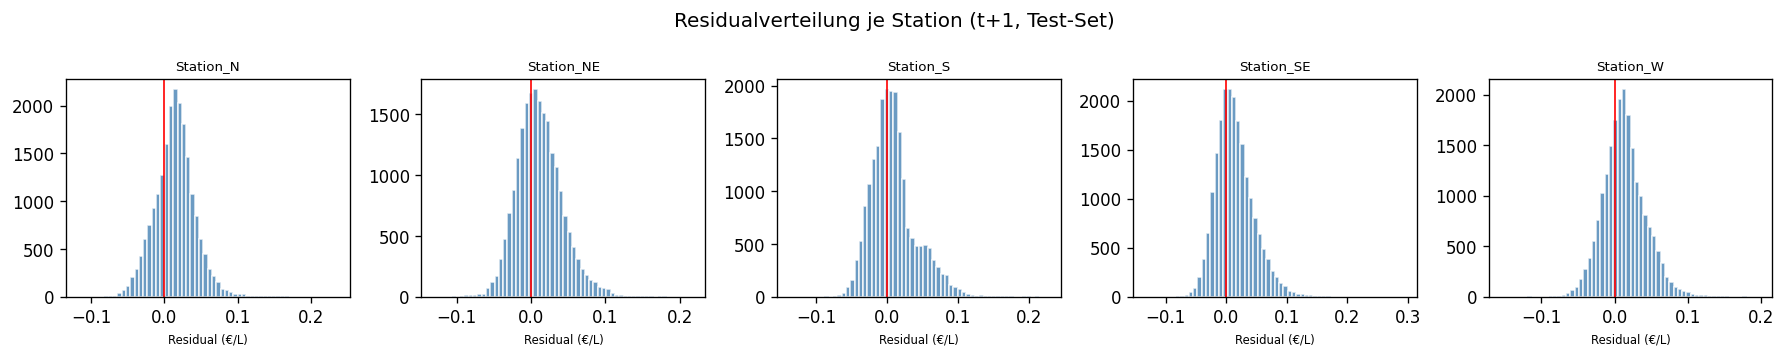

In [24]:
# Residualplots je Station (t+1)
y_test_t1 = y_test[[f'{c}_t+1h' for c in base_targets]].copy()
y_test_t1.columns = base_targets
y_pred_t1 = y_test_pred[[f'{c}_t+1h' for c in base_targets]].copy()
y_pred_t1.columns = base_targets

residuals = y_test_t1 - y_pred_t1

fig, axes = plt.subplots(1, n_stations, figsize=(3 * n_stations, 3))
if n_stations == 1:
    axes = [axes]
for ax, col in zip(axes, residuals.columns):
    ax.hist(residuals[col].dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', lw=1)
    ax.set_title(col.replace('diesel_', ''), fontsize=8)
    ax.set_xlabel('Residual (€/L)', fontsize=7)
fig.suptitle('Residualverteilung je Station (t+1, Test-Set)')
plt.tight_layout()
save_plot(plt, 'spedition_residuals_t1')
plt.show()

Plot saved: /Volumes/scratch-apfs-owc-1/PredAna_Python/SpritpreisAnalyse_HSAA_PredAnal/docs/2026-05-29-17-17-54_spedition_actual_vs_predicted_t1_8.png


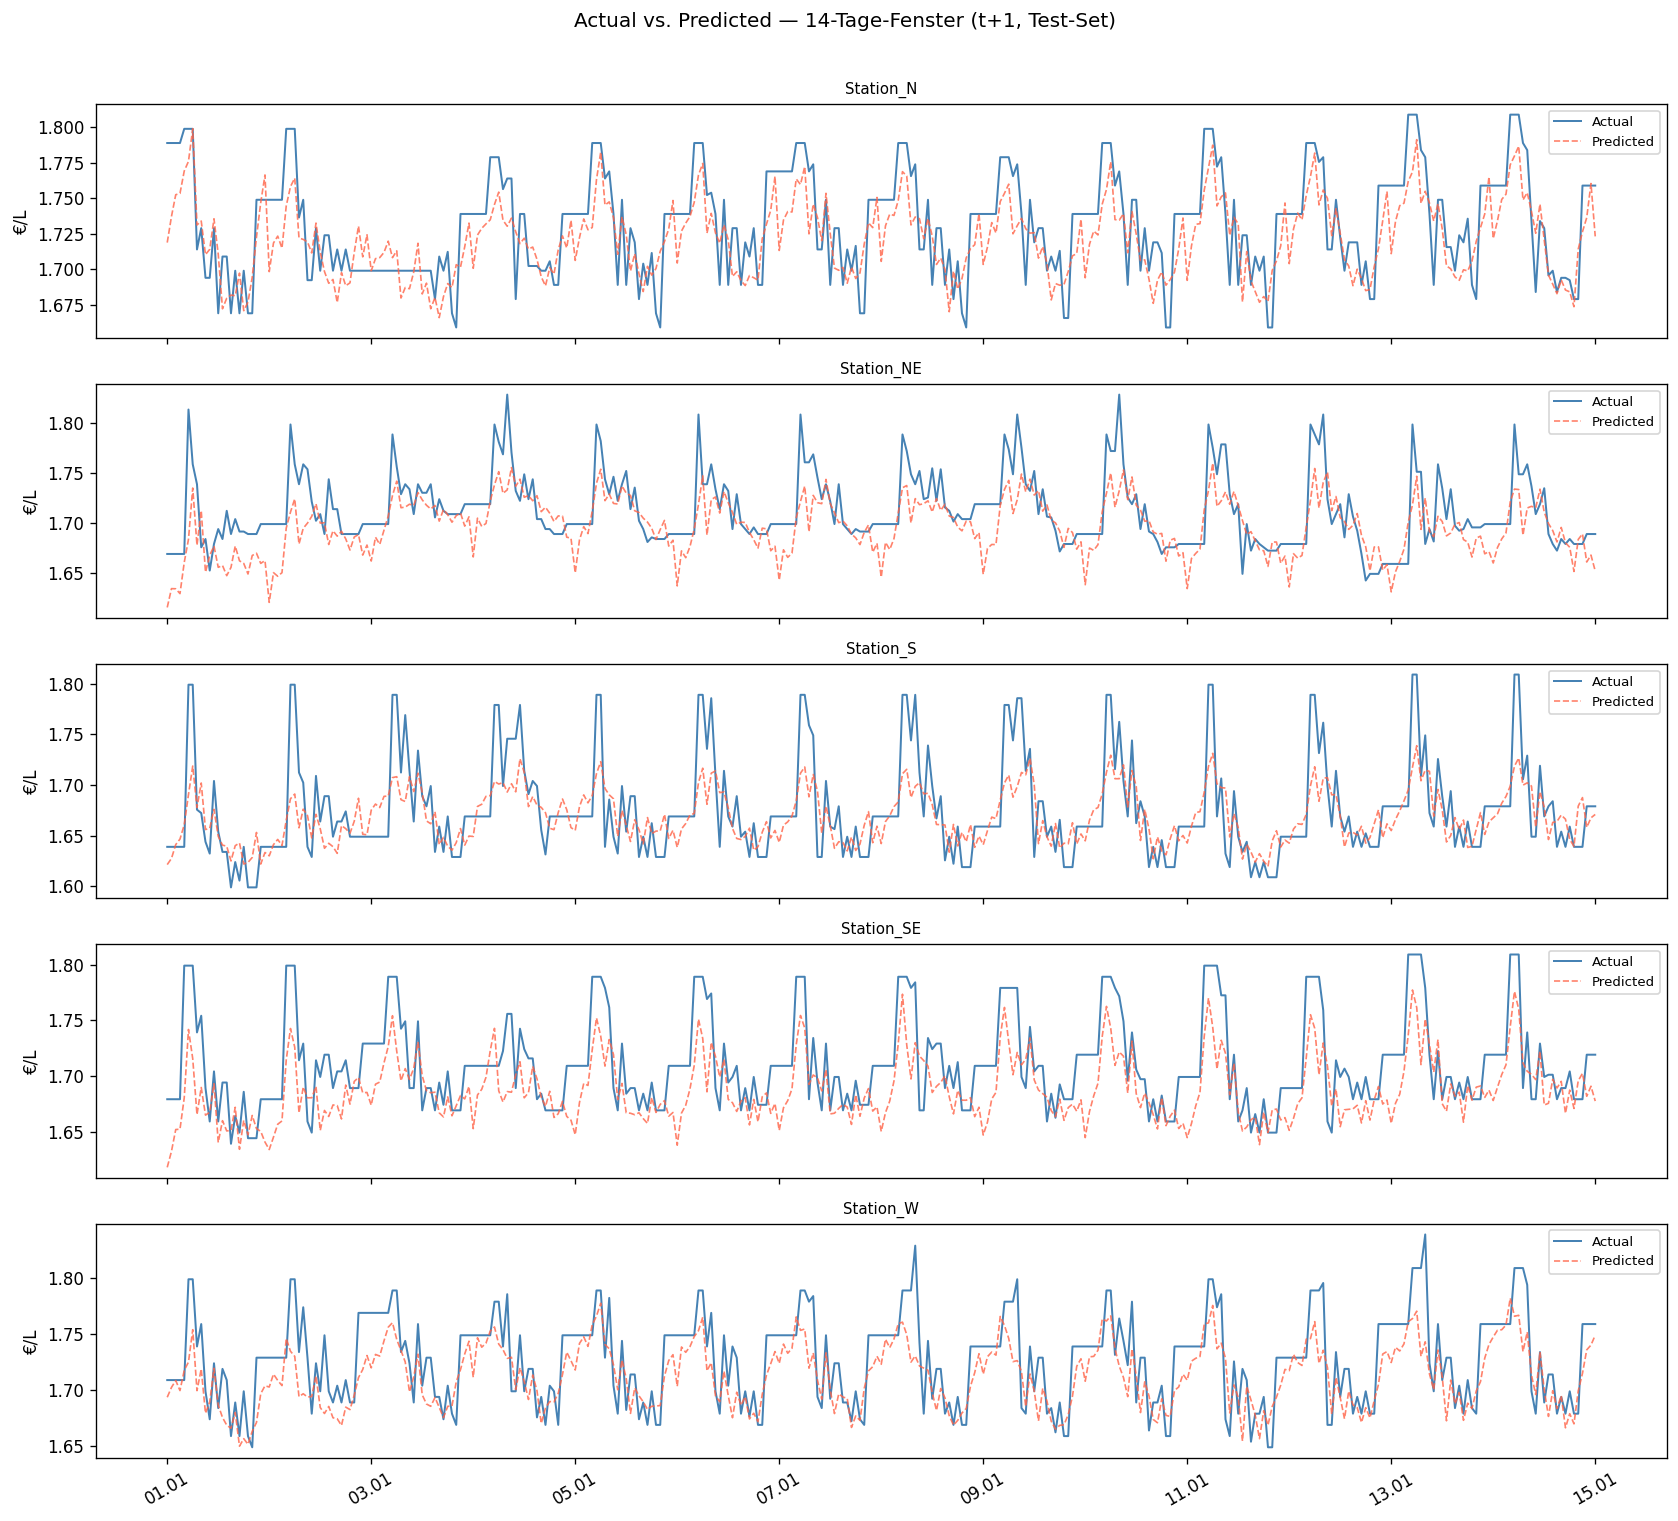

In [25]:
# Actual vs. Predicted — 14-Tage-Fenster
sample_end = y_test.index[0] + pd.Timedelta(days=14)
mask = y_test_t1.index <= sample_end

n_cols = min(n_stations, 5)
fig, axes = plt.subplots(n_cols, 1, figsize=(14, 2.5 * n_cols), sharex=True)
if n_cols == 1:
    axes = [axes]
for ax, col in zip(axes, y_test_t1.columns[:n_cols]):
    ax.plot(y_test_t1.index[mask], y_test_t1.loc[mask, col], lw=1.2,
            label='Actual', color='steelblue')
    ax.plot(y_pred_t1.index[mask], y_pred_t1.loc[mask, col],
            lw=1, ls='--', label='Predicted', color='tomato', alpha=0.8)
    ax.set_title(col.replace('diesel_', ''), fontsize=9)
    ax.set_ylabel('€/L')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
    ax.tick_params(axis='x', rotation=30)
fig.suptitle('Actual vs. Predicted — 14-Tage-Fenster (t+1, Test-Set)', y=1.01)
plt.tight_layout()
save_plot(plt, 'spedition_actual_vs_predicted_t1')
plt.show()

---
## §6 Deployment
Dispatch-Funktion: Gibt gerankte Stationsempfehlung für einen gewünschten Horizont aus.

In [26]:
def recommend_cheapest_station(
    loader: SpeditionDataLoader,
    model,
    scaler_X: StandardScaler,
    scaler_y: StandardScaler,
    X_data: pd.DataFrame,
    y_columns,
    horizon_h: int = 8,
) -> dict:
    """
    Gibt ein Ranking der 5 Stationen für Horizont +{horizon_h}h zurück.

    Returns dict mit:
      recommendation  — günstigste Station
      ranking         — geordnete Liste [(station, price), ...]
      spread_eur      — Preisdiff teuerste vs. günstigste × TANK_LITER
    """
    x_last = X_data.iloc[[-1]]
    y_scaled = model.predict(scaler_X.transform(x_last))
    pred = pd.Series(
        scaler_y.inverse_transform(y_scaled)[0],
        index=pd.Index(y_columns)
    )

    station_names = sorted({c.rsplit('_t+', 1)[0] for c in y_columns})
    prices = {
        s.replace('diesel_', ''): pred[f'{s}_t+{horizon_h}h']
        for s in station_names
    }
    ranking = sorted(prices.items(), key=lambda kv: kv[1])
    cheapest_name, cheapest_price = ranking[0]
    spread_eur = (ranking[-1][1] - ranking[0][1]) * TANK_LITER

    return {
        'horizon_h':      horizon_h,
        'recommendation': cheapest_name,
        'price':          cheapest_price,
        'ranking':        ranking,
        'spread_eur':     spread_eur,
    }

print('recommend_cheapest_station() definiert.')

recommend_cheapest_station() definiert.


In [27]:
# 72h-Forecast ab letztem Datenpunkt
def forecast_72h_direct(model, scaler_X, scaler_y, X_data, y_columns, base_targets, horizon=72):
    x_last = X_data.iloc[[-1]]
    y_scaled = model.predict(scaler_X.transform(x_last))
    pred = pd.Series(scaler_y.inverse_transform(y_scaled)[0], index=pd.Index(y_columns))
    last_ts = X_data.index[-1]
    rows = []
    for step in range(1, horizon + 1):
        row = {'timestamp': last_ts + pd.Timedelta(hours=step)}
        for s in base_targets:
            row[s] = pred[f'{s}_t+{step}h']
        rows.append(row)
    return pd.DataFrame(rows).set_index('timestamp')


df_forecast = forecast_72h_direct(
    model, scaler_X, scaler_y,
    X_test, y.columns.tolist(), base_targets, TARGET_HORIZON
)

# Dispatch-Ausgabe für verschiedene Horizonte
for h in [1, 8, 24, 48, 72]:
    rec = recommend_cheapest_station(
        loader, model, scaler_X, scaler_y,
        X_test, y.columns.tolist(), horizon_h=h
    )
    ranking_str = ' > '.join(f"{n} ({p:.3f})" for n, p in rec['ranking'])
    print(f'┌─ Dispatch Recommendation (t+{h:2d}h) ──────────────────────────────────')
    print(f'│  Günstigste: {rec["recommendation"]:20s} → {rec["price"]:.4f} €/L')
    print(f'│  Ranking   : {ranking_str}')
    print(f'│  Spread    : {rec["spread_eur"]:.2f} € ({TANK_LITER} L Tanke)')
    print(f'└──────────────────────────────────────────────────────────────────────')

┌─ Dispatch Recommendation (t+ 1h) ──────────────────────────────────
│  Günstigste: Station_S            → 1.9047 €/L
│  Ranking   : Station_S (1.905) > Station_W (1.924) > Station_N (1.942) > Station_NE (1.948) > Station_SE (1.952)
│  Spread    : 18.82 € (400 L Tanke)
└──────────────────────────────────────────────────────────────────────
┌─ Dispatch Recommendation (t+ 8h) ──────────────────────────────────
│  Günstigste: Station_N            → 1.9232 €/L
│  Ranking   : Station_N (1.923) > Station_S (1.945) > Station_NE (1.980) > Station_W (1.981) > Station_SE (2.012)
│  Spread    : 35.36 € (400 L Tanke)
└──────────────────────────────────────────────────────────────────────
┌─ Dispatch Recommendation (t+24h) ──────────────────────────────────
│  Günstigste: Station_S            → 1.9208 €/L
│  Ranking   : Station_S (1.921) > Station_N (1.950) > Station_W (1.954) > Station_NE (1.963) > Station_SE (1.965)
│  Spread    : 17.73 € (400 L Tanke)
└──────────────────────────────────────────

Plot saved: /Volumes/scratch-apfs-owc-1/PredAna_Python/SpritpreisAnalyse_HSAA_PredAnal/docs/2026-05-29-17-17-55_spedition_forecast_72h_direct_9.png


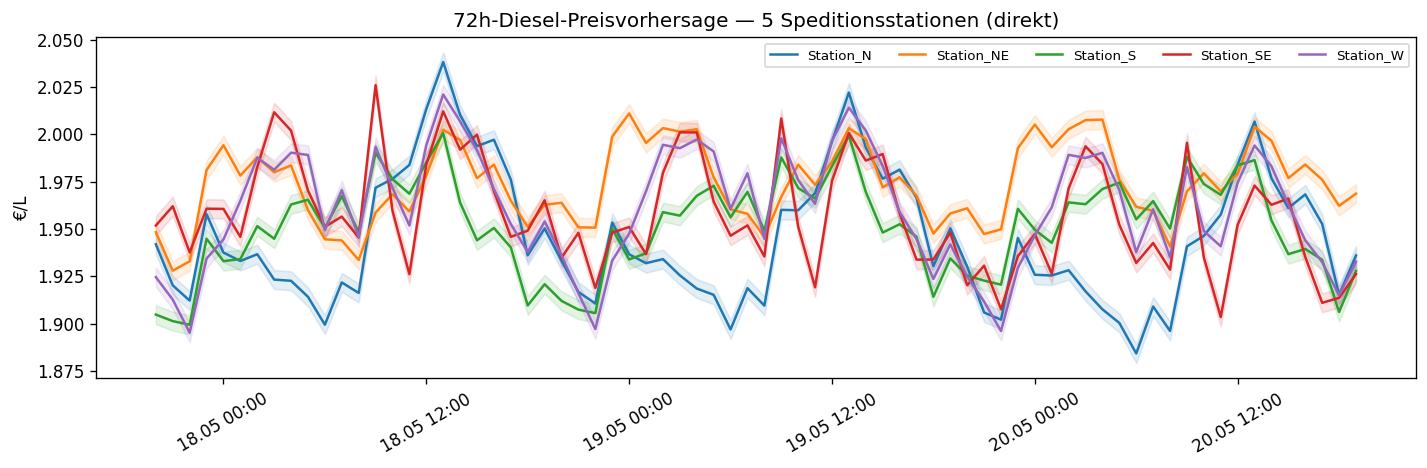

In [28]:
# 72h-Forecast visualisieren
fig, ax = plt.subplots(figsize=(12, 4))
colors = plt.cm.tab10.colors

for col, color in zip(df_forecast.columns, colors):
    label = col.replace('diesel_', '')
    ax.plot(df_forecast.index, df_forecast[col], lw=1.5, label=label, color=color)
    ax.fill_between(df_forecast.index,
                    df_forecast[col] - 0.005, df_forecast[col] + 0.005,
                    alpha=0.12, color=color)

ax.set(title='72h-Diesel-Preisvorhersage — 5 Speditionsstationen (direkt)',
       ylabel='€/L')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m %H:%M'))
ax.tick_params(axis='x', rotation=30)
ax.legend(ncol=5, fontsize=8)
plt.tight_layout()
save_plot(plt, 'spedition_forecast_72h_direct')
plt.show()

In [29]:
# Modell speichern
models_dir = os.path.join(project_root, 'data', 'models')
os.makedirs(models_dir, exist_ok=True)

model_path = os.path.join(models_dir, 'spedition_mlp.joblib')
joblib.dump({
    'model':          model,
    'scaler_X':       scaler_X,
    'scaler_y':       scaler_y,
    'station_uuids':  STATION_UUIDS,
    'base_targets':   base_targets,
    'forecast_horizon': TARGET_HORIZON,
    'trained_until':  str(X_train.index[-1]),
}, model_path)

print(f'Modell gespeichert: {model_path}')
print(f'Enthält: model, scaler_X, scaler_y, station_uuids, base_targets')

Modell gespeichert: /Volumes/scratch-apfs-owc-1/PredAna_Python/SpritpreisAnalyse_HSAA_PredAnal/data/models/spedition_mlp.joblib
Enthält: model, scaler_X, scaler_y, station_uuids, base_targets


## Notizen
Die finale Test-Evaluation ist methodisch sauber — der kritische Pfad (Scaler fit auf Train → Modell training → Test-Vorhersage) hat kein Leakage. Das einzige echte Problem ist die CV in cell-cv, die durch eine Pipeline behoben werden sollte. Die berichteten Test-Metriken (MAE=0.034 €/L, R²=0.929) sind zuverlässig.
